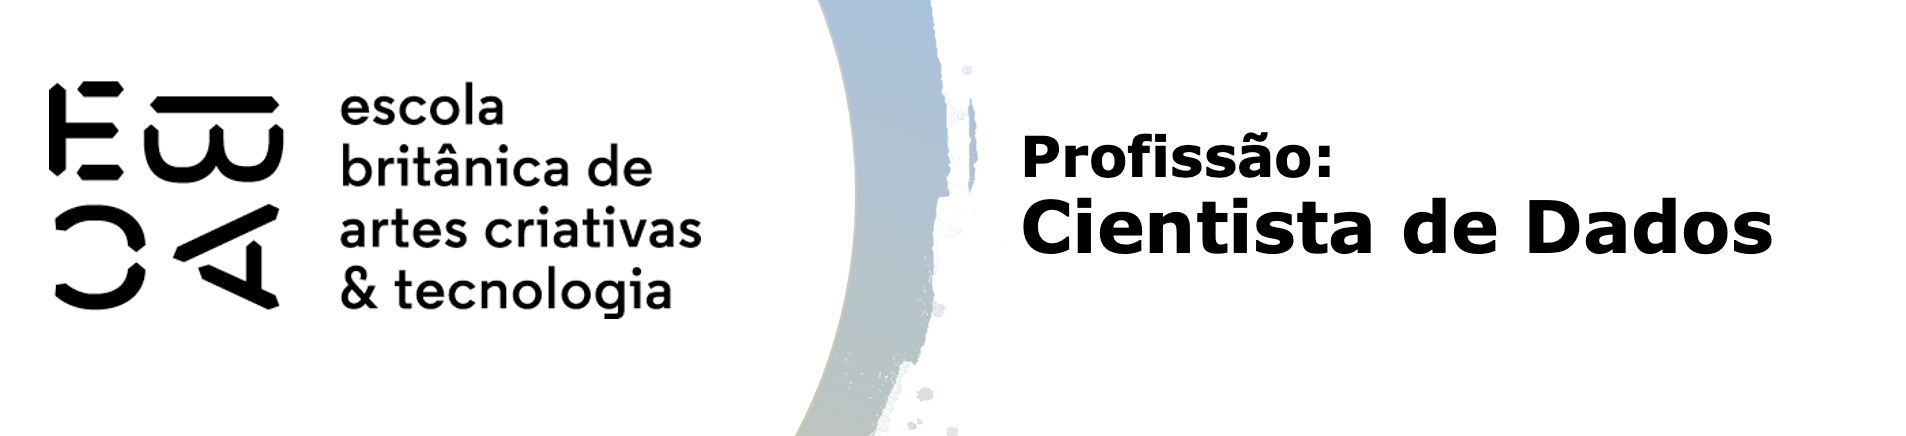

# Probabilidade - Tarefa

In [186]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import math
import matplotlib.ticker as mtick
import pandas as pd

from scipy.stats import norm 


1. Uma máquina embala ração para cachorro em pacotes de 15 kg, mas cada pacote produzido acaba tendo um peso aleatório, com distribuição Normal, com média 15kg, mas com desvio padrão 0,1 kg. Obtenha a probabilidade de que um pacote selecionado aleatoriamente dessa produção tenha mais que 15,2 kg.

In [187]:
# Gera com média 0 e desvio 1
z = np.random.randn(10000)

# Transforma para média 15, desvio 0.1
producao_de_racao = z * 0.1 + 15

In [188]:
producao_de_racao[producao_de_racao > 15.2 ]

array([15.27610734, 15.25488384, 15.27382597, 15.24487269, 15.2290762 ,
       15.22354626, 15.20497595, 15.2479313 , 15.31168743, 15.22271074,
       15.25428117, 15.24585287, 15.27203638, 15.25222134, 15.36531595,
       15.21008306, 15.21911163, 15.2276881 , 15.2007859 , 15.23071261,
       15.27030783, 15.20719147, 15.23052446, 15.2719006 , 15.25394156,
       15.23273495, 15.2335584 , 15.23762382, 15.24330217, 15.22299086,
       15.30454987, 15.21775159, 15.23446236, 15.23527673, 15.21852548,
       15.20433477, 15.2193061 , 15.28380395, 15.23084921, 15.24555321,
       15.20098633, 15.22362286, 15.22490307, 15.21595916, 15.24317299,
       15.21169901, 15.21640206, 15.20099403, 15.22053143, 15.22575088,
       15.21394256, 15.20231994, 15.25022907, 15.29197019, 15.23877492,
       15.22961709, 15.21096893, 15.21220905, 15.23397299, 15.22831407,
       15.2265808 , 15.2285176 , 15.27185609, 15.25742695, 15.22355781,
       15.25019642, 15.38179336, 15.25412433, 15.27135256, 15.20

In [189]:
producao_de_racao.mean()

14.9993841241286

A probabilidade para valores acima de 15,20 é de 0,26


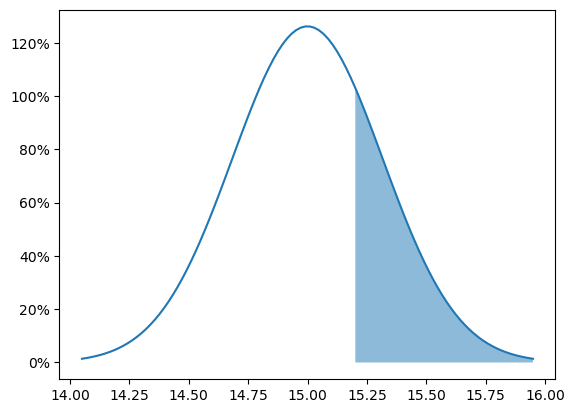

In [190]:
# Cria uma figura e um eixo para o gráfico
fig, ax = plt.subplots()

# Define a média e a variância da distribuição normal
mu = producao_de_racao.mean()
variance = 0.1

# Calcula o desvio padrão a partir da variância
sigma = math.sqrt(variance)

# Gera valores de x em torno da média, cobrindo 3 desvios padrão para cada lado
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)

# Calcula a densidade de probabilidade normal para cada valor de x
y = stats.norm.pdf(x, mu, sigma)

# Plota a curva da distribuição normal
ax.plot(x, y)

# Define o limite superior para a área sob a curva (1 desvio padrão acima da média)
std_lim = 1
low = 15.2

# Preenche a área sob a curva á partir  de 'low' 
plt.fill_between(x, y, where=(low < x) , alpha=.5)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))

# Calcula a probabilidade da variável estar entre 'low' e 'high'
prob_area = 1 - norm.cdf(low, mu, sigma) 

# Exibe a probabilidade calculada
print(f'A probabilidade para valores acima de {low :.2f} é de {prob_area:.2f}'.replace('.',','))

2. Da máquina descrita acima, obtenha o percentil de ordem 95% para o peso dos pacotes. Ou seja, o valor tal que a probabilidade de um pacote ter peso menor que este seja de 95%.

A probabilidade acumulada até 15,20 é de 0,74


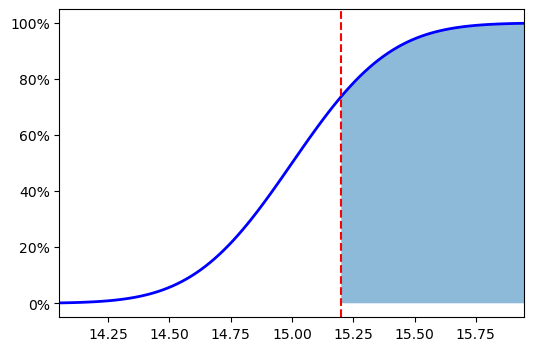

In [191]:
mu = 15.0
variance = 0.1
sigma = math.sqrt(variance)
low = 15.2

x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
y = norm.cdf(x, mu, sigma)

fig, ax = plt.subplots(figsize=(6, 4))

# Preencher a área acima de 15.2
plt.fill_between(x, y, where=(x > low), alpha=0.5)

# Agora sim: desenhar a curva por cima
ax.plot(x, y, color='blue', linewidth=2)

# Marcar a linha vertical em 15.2
ax.axvline(x=low, color='red', linestyle='--')

# Formatador do eixo y como porcentagem
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))

# Limites do eixo x
ax.set_xlim(mu - 3*sigma, mu + 3*sigma)

# Cálculo da área
prob_area = norm.cdf(low, mu, sigma)
print(f"A probabilidade acumulada até {low:.2f} é de {prob_area:.2f}".replace(".", ","))


3. Suponha duas variáveis aleatórias $Y_1$ e $Y_2$, a primeira com distribuição Normal Padrão (média=0, variância=1), a segunda com distribuição *t-studdent* com 5 graus de liberdade (também padrão). Calcule, para cada uma, a probabilidade de ser menor que cada um dos valores contidos no objeto $Y$ na célula abaixo:

In [192]:
Y=np.linspace(-6, 6, 200)
# Seu código começa aqui

mu = 0
variance = 1
sigma = math.sqrt(variance)

Y_1 = stats.norm.cdf(Y, mu, sigma)
Y_2 = stats.t.cdf(Y, 5)

y = Y_1
t= Y_2

x = Y

registro = pd.DataFrame({
    "Y": Y,
    "P(Y1 ≤ y) - Normal": Y_1,
    "P(Y2 ≤ y) - t(5)": Y_2,
    "Diferença": Y_2 - Y_1
})

In [193]:
registro

,Y,P(Y1 ≤ y) - Normal,P(Y2 ≤ y) - t(5),Diferença
0,-6.000000,9.865876e-10,0.000923,0.000923
1,-5.939698,1.427734e-09,0.000966,0.000966
2,-5.879397,2.058819e-09,0.001011,0.001011
3,-5.819095,2.958347e-09,0.001058,0.001058
4,-5.758794,4.235851e-09,0.001108,0.001108
...,...,...,...,...
195,5.758794,1.000000e+00,0.998892,-0.001108
196,5.819095,1.000000e+00,0.998942,-0.001058
197,5.879397,1.000000e+00,0.998989,-0.001011
198,5.939698,1.000000e+00,0.999034,-0.000966


4. Faça uma visualização gráfica dos dados do item anterior.

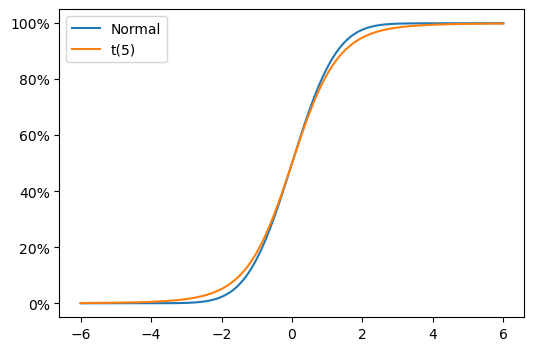

In [194]:
fig, ax = plt.subplots(figsize=(6,4))


ax.plot(x,y, label='Normal')
ax.plot(x,t, label=f't(5)')

ax.legend()

std_lim = 1
low = -1
high = mu+std_lim*sigma

# plt.fill_between(x, y, where=(low < x) & (x < high), alpha=.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))

# prob_area = norm.cdf(high, mu, sigma) - norm.cdf(low, mu, sigma)
# print(f'A probabilidade para valores entre {low:.2f} e {high:.2f} é de {prob_area:.2%}'.replace('.',','))

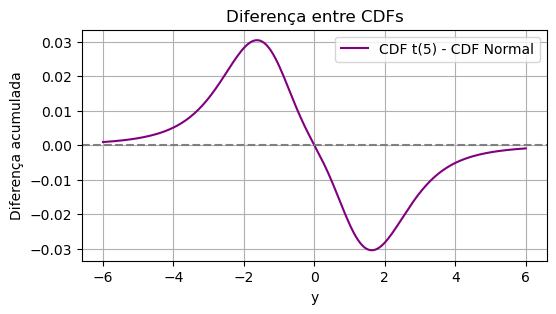

In [195]:
# Cria uma nova figura para o gráfico, com tamanho 6x3 polegadas
plt.figure(figsize=(6, 3))

# Plota a diferença entre as CDFs da t(5) e da Normal padrão para cada valor de Y
plt.plot(Y, Y_2 - Y_1, color="purple", label="CDF t(5) - CDF Normal")

# Adiciona uma linha horizontal em y=0 para referência visual
plt.axhline(0, color="gray", linestyle="--")

# Define o título do gráfico
plt.title("Diferença entre CDFs")

# Define o rótulo do eixo x
plt.xlabel("y")

# Define o rótulo do eixo y
plt.ylabel("Diferença acumulada")

# Adiciona a legenda ao gráfico
plt.legend()

# Adiciona uma grade ao gráfico para facilitar a visualização
plt.grid(True)


5. 3. Suponha duas variáveis aleatórias $Y_1$ e $Y_2$, a primeira com distribuição Normal Padrão (média=0, variância=1), a segunda com distribuição *t-studdent* com 5 graus de liberdade (também padrão). Calcule, para cada uma, o percentil (a inversa da *CDF*) para cada um dos valores do objeto *P* abaixo:

In [196]:
# Gera 20 valores igualmente espaçados entre 0 e 1 para representar probabilidades (percentis)
Y = np.linspace(0, 1, 20)

# Define os parâmetros da Normal padrão
mu = 0
variance = 1
sigma = math.sqrt(variance)

# Calcula o percentil (inversa da CDF) para cada valor de Y na Normal padrão
Y_1 = stats.norm.ppf(Y, mu, sigma)

# Calcula o percentil (inversa da CDF) para cada valor de Y na t de Student com 5 graus de liberdade
Y_2 = stats.t.ppf(Y, 5)

# Para facilitar a visualização, atribui os percentis a variáveis auxiliares
y = Y_1
t = Y_2

# Gera 20 valores igualmente espaçados no intervalo de -3 a 3 para o eixo x (não é usado diretamente aqui)
x = Y

# Cria um DataFrame para registrar os percentis das duas distribuições e a diferença entre eles
registro = pd.DataFrame({
    "Y": Y,
    "P(Y1 ≤ y) - Normal": Y_1,
    "P(Y2 ≤ y) - t(5)": Y_2,
    "Diferença": Y_2 - Y_1
})

C:\Users\hfasa\AppData\Local\Temp\ipykernel_7828\3925444843.py:27: RuntimeWarning: invalid value encountered in subtract
  "Diferença": Y_2 - Y_1


In [197]:
registro

,Y,P(Y1 ≤ y) - Normal,P(Y2 ≤ y) - t(5),Diferença
0,0.000000,-inf,-inf,NaN
1,0.052632,-1.619856,-1.974893,-0.355037
2,0.105263,-1.252120,-1.435859,-0.183740
3,0.157895,-1.003148,-1.114396,-0.111248
4,0.210526,-0.804596,-0.876124,-0.071528
5,0.263158,-0.633640,-0.680672,-0.047032
6,0.315789,-0.479506,-0.510277,-0.030771
7,0.368421,-0.336038,-0.355328,-0.019290
8,0.421053,-0.199201,-0.209799,-0.010598
9,0.473684,-0.066012,-0.069391,-0.003379


6. Faça um gráfico com os dados do item anterior.

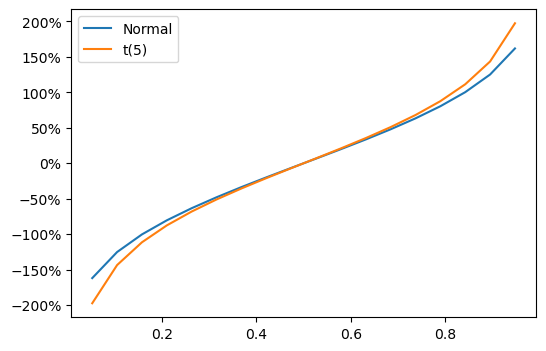

In [198]:
fig, ax = plt.subplots(figsize=(6,4))


ax.plot(x,y, label='Normal')
ax.plot(x,t, label=f't(5)')

ax.legend()

std_lim = 1
low = -1
high = mu+std_lim*sigma

# plt.fill_between(x, y, where=(low < x) & (x < high), alpha=.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))

# prob_area = norm.cdf(high, mu, sigma) - norm.cdf(low, mu, sigma)
# print(f'A probabilidade para valores entre {low:.2f} e {high:.2f} é de {prob_area:.2%}'.replace('.',','))

C:\Users\hfasa\AppData\Local\Temp\ipykernel_7828\3734436679.py:5: RuntimeWarning: invalid value encountered in subtract
  plt.plot(Y, Y_2 - Y_1, color="purple", label="CDF t(5) - CDF Normal")


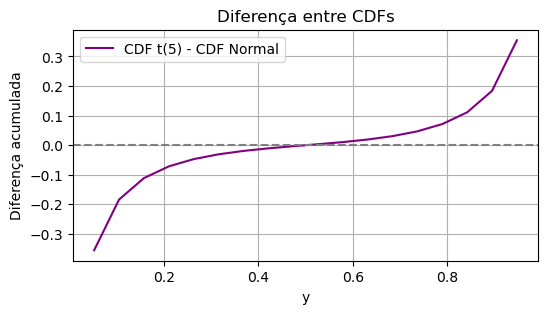

In [199]:
# Cria uma nova figura para o gráfico, com tamanho 6x3 polegadas
plt.figure(figsize=(6, 3))

# Plota a diferença entre as CDFs da t(5) e da Normal padrão para cada valor de Y
plt.plot(Y, Y_2 - Y_1, color="purple", label="CDF t(5) - CDF Normal")

# Adiciona uma linha horizontal em y=0 para referência visual
plt.axhline(0, color="gray", linestyle="--")

# Define o título do gráfico
plt.title("Diferença entre CDFs")

# Define o rótulo do eixo x
plt.xlabel("y")

# Define o rótulo do eixo y
plt.ylabel("Diferença acumulada")

# Adiciona a legenda ao gráfico
plt.legend()

# Adiciona uma grade ao gráfico para facilitar a visualização
plt.grid(True)
